In [1]:
import os
import json
import gzip
import pandas as pd
import numpy as np

import statsmodels.api as sm

import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as transforms

import seaborn as sns

from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')


In [ ]:
filename_suffix='noselfauthor_bootstrap'

dfself_vars = pd.read_csv('../data/clean/bootstrap_noselfauthor_R_disruption_03172026.csv')

In [3]:
def identify_top_performers(df, performance_col='normalized_frac_top', percentile=75):
    """
    Identify top performers based on annual percentiles
    """
    df = df.copy()
    
    df['annual_percentile'] = df.groupby('Year')[performance_col].rank(pct=True) * 100
    
    df['top_performer'] = (df['annual_percentile'] >= percentile).astype(int)
    
    return df

dfself = identify_top_performers(dfself_vars, performance_col='normalized_frac_top', percentile=75)

dfself['performer_group'] = dfself['top_performer'].map({1: 'Top Performers', 0: 'Others'})


In [4]:
dfself

,CitingCountry,Year,Country,AUC,N,STD,zscore,pvalue,significant,NumPub,...,novel_pct10_rate,disruption_mean,disrupt_top10_rate,disrupt_top5_rate,novel_pct10_rate_norm,hit_rate,hit_rate_scinet,annual_percentile,top_performer,performer_group
0,AE,2005,AE,0.522007,57,0.019949,1.103144,1.349823e-01,False,805,...,0.169499,0.004254,0.245540,0.102379,0.963190,0.082885,0.107570,49.397590,0,Others
1,AE,2006,AE,0.535211,73,0.018011,1.954971,2.529327e-02,False,920,...,0.186072,0.003256,0.276025,0.108814,1.075293,0.091996,0.110084,54.117647,0,Others
2,AE,2007,AE,0.520049,66,0.019021,1.054066,1.459264e-01,False,991,...,0.163540,0.002334,0.297686,0.119762,0.917841,0.107114,0.115356,43.678161,0,Others
3,AE,2008,AE,0.526826,88,0.014461,1.854976,3.179984e-02,False,1155,...,0.167653,0.002940,0.307692,0.116653,0.906043,0.105720,0.111984,39.560440,0,Others
4,AE,2009,AE,0.565627,95,0.017381,3.775801,7.974724e-05,True,1258,...,0.143354,0.002917,0.286957,0.113540,0.765525,0.117801,0.125808,57.142857,0,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2496,ZW,2015,ZW,0.546007,146,0.011815,3.893942,4.931419e-05,True,1125,...,0.248309,0.004065,0.359420,0.137198,1.204324,0.088235,0.077502,26.956522,0,Others
2497,ZW,2016,ZW,0.579939,176,0.012825,6.232976,2.288284e-10,True,994,...,0.240192,0.002948,0.379349,0.139526,1.183107,0.109721,0.108581,19.327731,0,Others
2498,ZW,2017,ZW,0.566057,230,0.009910,6.665361,1.320079e-11,True,1207,...,0.269914,0.006163,0.324755,0.137255,1.269811,0.111916,0.109104,31.200000,0,Others
2499,ZW,2018,ZW,0.567694,195,0.012286,5.510086,1.793293e-08,True,1199,...,0.234905,0.001578,0.327426,0.125263,1.130124,0.093502,0.086774,35.937500,0,Others


In [5]:
def analyze_quadrant_top_performer_probability(df, self_reliance_col='logzscore', 
                                              collaboration_col='FracInternationalAuthors',                                              decade_col='Decade'):
    """
    Analyze the probability of each quadrant being a top performer by decade
    
    This calculates: P(top performer | quadrant) for each quadrant
    
    Parameters:
    df: DataFrame with country performance data
    self_reliance_col: 'logzscore' - higher values = higher self-reliance
    collaboration_col: 'FracInternationalAuthors' - higher values = higher collaboration
    decade_col: Column name for decade (create if needed)
    """
    
    df = df.copy()
    
   
    if decade_col not in df.columns:
        df[decade_col] = (df['Year'] // 10) * 10
    
    def categorize_quadrant(row, self_threshold, collab_threshold):
        """Categorize countries into quadrants based on thresholds"""
        high_self = row[self_reliance_col] >= self_threshold
        high_collab = row[collaboration_col] >= collab_threshold
        
        if high_self and high_collab:
            return "Self-sufficient collaborators" 
        elif high_self and not high_collab:
            return "Independent nations"
        elif not high_self and high_collab:
            return "Dependent collaborators"
        else:
            return "Peripheral nations"
    
    results = []
    all_data_with_quadrants = []
    
   
    for decade in range(1990, 2020, 1):  
        decade_data = df[df['Year'] == decade].copy()
        
        if len(decade_data) == 0:
            continue
            
        self_median = decade_data[self_reliance_col].median()
        collab_median = decade_data[collaboration_col].median()
        
        decade_data['quadrant'] = decade_data.apply(
            lambda row: categorize_quadrant(row, self_median, collab_median), 
            axis=1
        )
        
        for quadrant in ["Self-sufficient collaborators", "Independent nations", 
                        "Dependent collaborators", "Peripheral nations"]:
            
            quadrant_data = decade_data[decade_data['quadrant'] == quadrant]
            total_in_quadrant = len(quadrant_data)
            
            if total_in_quadrant > 0:
               
                top_performers_in_quadrant = len(quadrant_data[quadrant_data['top_performer'] == 1])
                
               
                probability = top_performers_in_quadrant / total_in_quadrant
                
                results.append({
                    'Year': decade,
                    'Quadrant': quadrant,
                    'Total_Countries_in_Quadrant': total_in_quadrant,
                    'Top_Performers_in_Quadrant': top_performers_in_quadrant,
                    'Probability_Top_Performer': probability,
                    'Self_Threshold': self_median,
                    'Collab_Threshold': collab_median
                })
        
       
        all_data_with_quadrants.append(decade_data)
    
 
    combined_data = pd.concat(all_data_with_quadrants, ignore_index=True) if all_data_with_quadrants else pd.DataFrame()
    
    return pd.DataFrame(results), combined_data


In [6]:
select_df=dfself.groupby('Country').count()[['Year']].reset_index()
select_countries=select_df[select_df['Year']>=10]['Country'].to_list()

print(f'number of countries with more then 10-years of observations: {len(select_countries)}')

probability_results, data_with_quadrants = analyze_quadrant_top_performer_probability(dfself[dfself['Country'].isin(select_countries)])

number of countries with more then 10-years of observations: 99


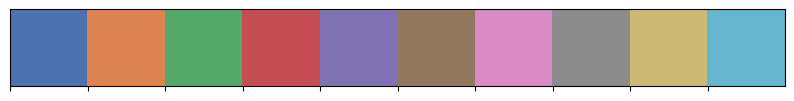

In [7]:
sns_deep = sns.color_palette("deep")
sns.palplot(sns_deep)

# Figure 5 Panel A

In [ ]:
custom_params = {"axes.spines.bottom": True, "axes.spines.right": False, "axes.spines.top": False,
                 "axes.spines.left": True,"ytick.left":True, "xtick.bottom":True}
sns.set_theme(style='ticks', rc=custom_params)

def quadrant_probability(subax):

  
    sns_deep = sns.color_palette("deep", 10)
    
    colours=['#8D95A0','#2171b5','#DA6437',]
    
    custom_palette = {
        'Independent nations': colours[2],  # Blue
        'Self-sufficient collaborators': colours[1],            # Orange  
        'Dependent collaborators': sns_deep[4],   # Green
        'Peripheral nations': colours[0]                  # Gray
    }
    
    ax = sns.lineplot(data=probability_results, x='Year', y='Probability_Top_Performer', 
                      hue='Quadrant', palette=custom_palette,
                      lw=2.5, marker='o', markersize=10, ax=subax) 
    ax.tick_params( rotation=0, labelsize=25)
    ax.set_xlabel('Year', fontsize=30)
    ax.set_ylabel('Proportion of top performers', fontsize=30)
    
    ax.legend(frameon=False, fontsize=25, loc='upper center', ncol=1,  
        bbox_to_anchor=(0.75, 1.05) )

    ax.set_ylim([-0.1,1.2])
    
    #plt.savefig('../output/figures/proportion_top_performers.pdf', bbox_inches='tight')

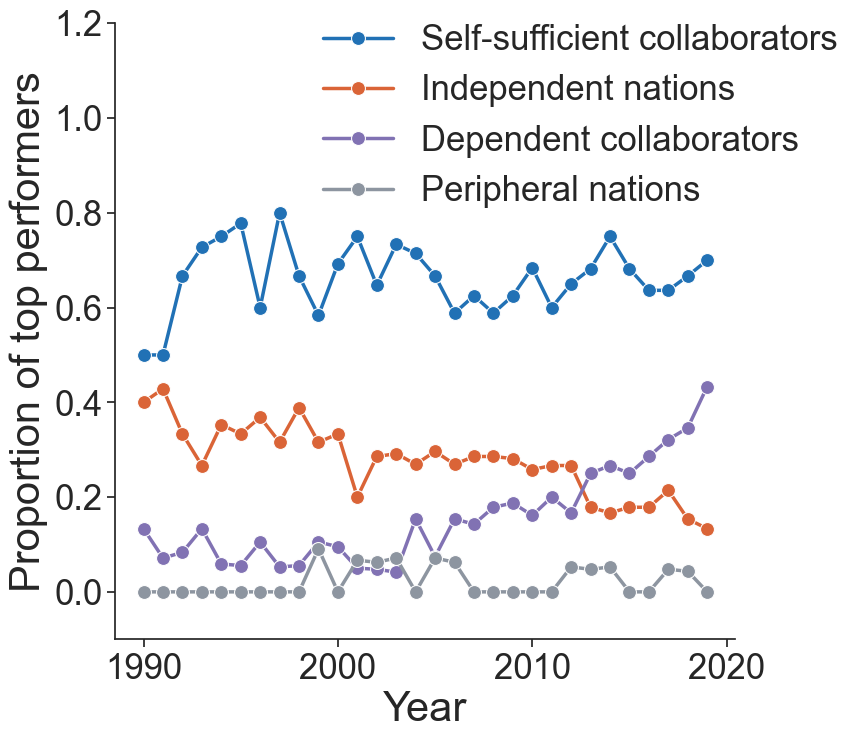

In [9]:
fig, ax= plt.subplots(1,1, figsize=(8,8))
quadrant_probability(ax)

# Figure S12

In [10]:
def create_country_quadrant_evolution(df, country_col='Country', year_col='Year', 
                                   quadrant_col='quadrant', top_n_countries=None):
    """
    Create parallel plot with countries on y-axis, years on x-axis, colored by quadrant
    """
    
    sns_deep = sns.color_palette("deep", 10)
    colours=['#8D95A0','#2171b5','#DA6437',]
    
    quadrant_colors = {
        'Self-sufficient collaborators': colours[1],    
        'Independent nations': colours[2],  
        'Dependent collaborators': sns_deep[4],   
        'Peripheral nations': colours[0]              
    }
    
  
    df_plot = df.copy()
    years = sorted(df_plot[year_col].unique())
    
    # Select countries to display
    if top_n_countries:
        country_counts = df_plot[country_col].value_counts()
        selected_countries = country_counts.head(top_n_countries).index.tolist()
        df_plot = df_plot[df_plot[country_col].isin(selected_countries)]
    
    # Define quadrant order for grouping (from top to bottom in plot)
    quadrant_order = ['Self-sufficient collaborators','Independent nations', 'Dependent collaborators', 'Peripheral nations']
    
    # Group countries by their primary quadrant (most years spent)
    quadrant_groups = {quadrant: [] for quadrant in quadrant_order}
    
    for country in df_plot[country_col].unique():
        country_data = df_plot[df_plot[country_col] == country]
        
        quadrant_counts = {}
        for quadrant in quadrant_order:
            count = len(country_data[country_data[quadrant_col] == quadrant])
            quadrant_counts[quadrant] = count
        
        max_count = max(quadrant_counts.values())
        primary_quadrant = None
        for quadrant in quadrant_order:
            if quadrant_counts[quadrant] == max_count:
                primary_quadrant = quadrant
                break
        
        total_years = len(country_data)
        
        quadrant_groups[primary_quadrant].append((country, total_years))
    
    countries = []
    for quadrant in quadrant_order:
        group_countries = sorted(quadrant_groups[quadrant], key=lambda x: (-x[1], x[0]))
        countries.extend([country for country, _ in group_countries])
    
    countries.reverse()
    
  
    fig, ax = plt.subplots(figsize=(15, max(8, len(countries)*0.3)))
    
    
    for i, country in enumerate(countries):
        country_data = df_plot[df_plot[country_col] == country]
        
        for _, row in country_data.iterrows():
            year = row[year_col]
            quadrant = row[quadrant_col]
            color = quadrant_colors.get(quadrant, 'gray')
            
            ax.scatter(year, i, c=color, s=120, alpha=0.8, edgecolors='white', linewidth=1)
        
        if len(country_data) > 1:
            years_country = sorted(country_data[year_col].unique())
            y_positions = [i] * len(years_country)
            ax.plot(years_country, y_positions, 'k-', alpha=0.3, linewidth=1, zorder=0)
    
 
    
    ax.set_xlabel('Year', fontsize=25, fontweight='bold')
    ax.set_ylabel('Country', fontsize=25, fontweight='bold')
    ax.tick_params(labelsize=18, direction='out', length=4, width=0)
    ax.tick_params(axis='x', rotation=90)
    
    ax.set_yticks(range(len(countries)))
    ax.set_yticklabels(countries)
    ax.set_xticks(years)
    ax.set_xlim(min(years) - 0.5, max(years) + 0.5)
    ax.set_ylim(-0.5, len(countries) - 0.5)
    
   
    ax.grid(True, alpha=0.3)
    
    legend_elements = [plt.scatter([], [], c=color, s=100, label=quadrant, alpha=0.8, edgecolors='white')
                      for quadrant, color in quadrant_colors.items()]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=20)
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()


In [ ]:
create_country_quadrant_evolution(data_with_quadrants, country_col='Country', year_col='Year', 
                                   quadrant_col='quadrant', top_n_countries=None)

plt.savefig('../output/figures/SI_transition_evolution_bootstrap.pdf', bbox_inches='tight')

# Figure 5 Panel B

In [11]:
def analyze_quadrant_transitions_annual(df, self_reliance_col='logzscore', 
                               collaboration_col='FracInternationalAuthors'):
    """
    Analyze countries that change quadrant classifications over time
    Uses annual dynamic thresholds (medians calculated for each year)
    
    Returns:
    - transition_summary: Summary of transition patterns
    - country_transitions: Detailed country-level transitions
    - stable_countries: Countries that never change quadrants
    """
    
    df = df.copy()
    
    def categorize_quadrant(row, self_threshold, collab_threshold):
        """Categorize countries into quadrants based on thresholds"""
        high_self = row[self_reliance_col] >= self_threshold
        high_collab = row[collaboration_col] >= collab_threshold
        
        if high_self and high_collab:
            return "Self-sufficient collaborators"
        elif high_self and not high_collab:
            return  "Independent nations"
        elif not high_self and high_collab:
            return "Dependent collaborators"
        else:
            return "Peripheral nations"
    
    # Store all data with annual quadrant classifications
    all_data_with_quadrants = []
    
    # Calculate quadrants for each year using annual thresholds
    for year in sorted(df['Year'].unique()):
        year_data = df[df['Year'] == year].copy()
        
        if len(year_data) == 0:
            continue
            
        # Calculate medians for this year (dynamic thresholds)
        self_median = year_data[self_reliance_col].median()
        collab_median = year_data[collaboration_col].median()
        
        # Categorize into quadrants using annual thresholds
        year_data['quadrant'] = year_data.apply(
            lambda row: categorize_quadrant(row, self_median, collab_median), 
            axis=1
        )
        
        # Store thresholds used for this year
        year_data['self_threshold'] = self_median
        year_data['collab_threshold'] = collab_median
        
        all_data_with_quadrants.append(year_data)
    
    # Combine all years back into one DataFrame
    df_with_quadrants = pd.concat(all_data_with_quadrants, ignore_index=True)
    
    # Track quadrant changes by country
    country_quadrants = df_with_quadrants.groupby('Country')['quadrant'].apply(list).to_dict()
    country_years = df_with_quadrants.groupby('Country')['Year'].apply(list).to_dict()
       
    stable_countries = []
    changing_countries = []
    transition_patterns = []
    
    for country, quadrants in country_quadrants.items():
        unique_quadrants = list(set(quadrants))
        years = country_years[country]
        
        if len(unique_quadrants) == 1:
            # Stable country
            stable_countries.append({
                'Country': country,
                'Stable_Quadrant': unique_quadrants[0],
                'Years_Observed': len(quadrants),
                'Year_Range': f"{min(years)}-{max(years)}"
            })
        else:
            # Changing country
            # Track year-to-year transitions
            country_data = df_with_quadrants[df_with_quadrants['Country'] == country].sort_values('Year')
            transitions = []
            
            for i in range(len(country_data) - 1):
                current_quad = country_data.iloc[i]['quadrant']
                next_quad = country_data.iloc[i + 1]['quadrant']
                current_year = country_data.iloc[i]['Year']
                next_year = country_data.iloc[i + 1]['Year']
                
                if current_quad != next_quad:
                    transitions.append(f"{current_quad} -> {next_quad} ({current_year}-{next_year})")
                    transition_patterns.append({
                        'Country': country,
                        'From_Quadrant': current_quad,
                        'To_Quadrant': next_quad,
                        'From_Year': current_year,
                        'To_Year': next_year
                    })
                        
            changing_countries.append({
                'Country': country,
                'All_Quadrants': unique_quadrants,
                'Num_Quadrants': len(unique_quadrants),
                'Transitions': transitions,
                'Years_Observed': len(quadrants),
                'Year_Range': f"{min(years)}-{max(years)}"
            })
    
    # Summarize transition patterns
    if transition_patterns:
        transition_df = pd.DataFrame(transition_patterns)
        transition_summary = transition_df.groupby(['From_Quadrant', 'To_Quadrant']).size().reset_index(name='Count')
        transition_summary = transition_summary.sort_values('Count', ascending=False)
    else:
        transition_summary = pd.DataFrame(columns=['From_Quadrant', 'To_Quadrant', 'Count'])
    
    return (pd.DataFrame(transition_summary), 
            pd.DataFrame(changing_countries), 
            pd.DataFrame(stable_countries), df_with_quadrants) 

    

In [12]:
select_df=dfself.groupby('Country').count()[['Year']].reset_index()
select_countries=select_df[select_df['Year']>=10]['Country'].to_list()
len(select_countries)

transition_summary, changing_countries, stable_countries, df_with_quadrants  = analyze_quadrant_transitions_annual(dfself[dfself['Country'].isin(select_countries)])

print(stable_countries.shape)

(24, 4)


In [13]:
import networkx as nx

colours=['#8D95A0','#2171b5','#DA6437',]


def plot_chord_diagram(transition_summary, ax=None):
    """Network diagram showing transition flows"""
    
    if len(transition_summary) == 0:
        print("No transitions to visualize")
        return
        
    quadrants = [ "Independent nations","Self-sufficient collaborators","Dependent collaborators", 
                 "Peripheral nations"]
    
    colours=['#8D95A0', '#2171b5', '#DA6437']
    sns_deep = sns.color_palette("deep", 10)
    
    quadrant_colors = {
        'Self-sufficient collaborators': colours[1], 
        'Independent nations': colours[2],  # Blue
        'Dependent collaborators': sns_deep[4],   # Green
        'Peripheral nations': colours[0]                  # Gray
    }
    
    n = len(quadrants)
    matrix = np.zeros((n, n))
    
    quad_to_idx = {quad: i for i, quad in enumerate(quadrants)}
    
    for _, row in transition_summary.iterrows():  # Fixed syntax error here
        from_idx = quad_to_idx[row['From_Quadrant']]
        to_idx = quad_to_idx[row['To_Quadrant']]
        matrix[from_idx, to_idx] = row['Count']
    
    if ax is None:
        plt.figure(figsize=(10, 10))
        ax = plt.gca()
    
    G = nx.DiGraph()
    
    for i, quad in enumerate(quadrants):
        G.add_node(i, label=quad)
    
    # Add edges with weights
    for i in range(n):
        for j in range(n):
            if matrix[i, j] > 0:
                G.add_edge(i, j, weight=matrix[i, j])
    
    # Position nodes in a circle
    pos = {}
    for i, quad in enumerate(quadrants):
        angle = 2 * np.pi * i / len(quadrants)
        pos[i] = (np.cos(angle), np.sin(angle))
    
    # Calculate node radius for edge alignment
    node_radius = np.sqrt(150) / 120
    
    # Draw edges FIRST with alignment to node boundaries
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    max_weight = max(weights) if weights else 1
    
    for (u, v), weight in zip(edges, weights):
        # Get node positions
        start_pos = np.array(pos[u])
        end_pos = np.array(pos[v])
        
        # Calculate direction vector
        direction = end_pos - start_pos
        direction_norm = direction / np.linalg.norm(direction)
        
        # Adjust positions to node edges
        adjusted_start = start_pos + direction_norm * node_radius
        adjusted_end = end_pos - direction_norm * node_radius
        
        # Create temporary positions for this edge
        temp_pos = {u: adjusted_start, v: adjusted_end}
        
        nx.draw_networkx_edges(G, temp_pos, [(u, v)], width=weight/max_weight*7,
                             alpha=1, edge_color=colours[0], 
                             connectionstyle="arc3,rad=0.2",
                             arrowsize=22, ax=ax)  # Added ax parameter
    
    # Draw nodes SECOND (on top of edges) with quadrant-specific colors
    node_colors = [quadrant_colors[quadrants[i]] for i in range(len(quadrants))]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                          node_size=1800, alpha=0.8, ax=ax)
    
    # Add labels LAST with rotation for specific quadrants
    labels = {i: quad.replace(' ', '\n') for i, quad in enumerate(quadrants)}
    
    # Manual rotation based on quadrant names/indices
    rotation_map = {
        0: -90,    # Self-Sufficient (top)
        1: 0,  # Independent Collaborators (right) 
        2: 90,    # Dependent Collaborators (bottom)
        3: 0    # Peripheral (left)
    }

    label_offset = 1.25
    
    for i, (x, y) in pos.items():
        
        label = labels[i]
        rotation = rotation_map.get(i, 0)
        label_color = quadrant_colors[quadrants[i]]
        
        ax.text(x*label_offset, y*label_offset, label, 
                fontsize=30, 
                ha='center', 
                va='center',
                rotation=rotation,
                color='black', alpha=1,
                #weight='bold'
            )        
    
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect('equal')
    
    ax.axis('off')  
    
    return ax  

In [ ]:
transition_selected=transition_summary[transition_summary['Count']>=1]


fig, ax=plt.subplots(1,1, figsize=(8,8))
plot_chord_diagram(transition_selected, ax=ax)

#plt.savefig('../output/figures/quantile_transition.pdf', bbox_inches='tight')

# Figure 5 Panel C

In [ ]:
filename_suffix='noselfauthor_bootstrap'
dfself_vars = pd.read_csv('../data/clean/bootstrap_noselfauthor_R_disruption_03172026.csv')

num_years=10
filtered_data = dfself_vars.groupby('Country').filter(lambda x: len(x) >= num_years)


filtered_data['top_percentile'] = filtered_data.groupby('Year')['normalized_frac_top'] \
    .transform(lambda x: x.rank(pct=True) * 100)


def change_between_available_end(filtered_data):
    # Step 2: Group by country and compute metrics
    result = (
        filtered_data.groupby("Country")
        .agg(
            First_Year=("Year", "first"),
            Last_Year=("Year", "last"),
            international_Change=("FracInternationalAuthors", lambda x: x.iloc[-1] - x.iloc[0]),
            international_PctChange=("FracInternationalAuthors", lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] if x.iloc[0] != 0 else None),
            international_AnnualGrowth=("FracInternationalAuthors", lambda x: ((x.iloc[-1] / x.iloc[0]) ** (1 / (len(x) - 1)) - 1) * 100 if x.iloc[0] > 0 and len(x) > 1 else None),
            self_Change=("logzscore", lambda x: x.iloc[-1] - x.iloc[0]),
            self_PctChange=("logzscore", lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] if x.iloc[0] != 0 else None),
            self_AnnualGrowth=("logzscore", lambda x: ((x.iloc[-1] / x.iloc[0]) ** (1 / (len(x) - 1)) - 1) * 100 if x.iloc[0] > 0 and len(x) > 1 else None),
            top_Change=('normalized_frac_top', lambda x: x.iloc[-1] - x.iloc[0]),
            top_PctChange=('normalized_frac_top',lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] if x.iloc[0] != 0 else None ),
            top_AnnualGrowth=('normalized_frac_top', lambda x: ((x.iloc[-1] / x.iloc[0]) ** (1 / (len(x) - 1)) - 1) * 100 if x.iloc[0] > 0 and len(x) > 1 else None),
            top_PctRankStart=('top_percentile', lambda x: x.iloc[0]),
            top_PctRankEnd=('top_percentile', lambda x: x.iloc[-1]),
            top_PctRankChange=('top_percentile', lambda x: x.iloc[-1] - x.iloc[0]),
            GDP_PctChange=('GDP_PCAP',lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] if x.iloc[0] != 0 else None ),
            RND_PctChange=('RND_per',lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] if x.iloc[0] != 0 else None ),
            RND_AnnualGrowth=('RND_per', lambda x: ((x.iloc[-1] / x.iloc[0]) ** (1 / (len(x) - 1)) - 1) * 100 if x.iloc[0] > 0 and len(x) > 1 else None),
            NR_PctChange=('NResearchers',lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] if x.iloc[0] != 0 else None ),
            RND_avarage=('RND_per', lambda x:x.mean())
           
        )
        .reset_index()
    )

    result['top_annual_group'] = pd.qcut(
        result['top_AnnualGrowth'],
        q=[0, 0.5, 0.75, 1.0],
        labels=['Bottom 50%', '50–75%', 'Top 25%']
    )
    
    result['RND_group'] = pd.qcut(
        result['RND_avarage'],
        q=[0, 0.5, 0.75, 1.0],
        labels=['Bottom 50%', '50–75%', 'Top 25%']
    )

    return result

In [16]:
# countries_with_2000_data = filtered_data[filtered_data['Year'] == 1990]['Country'].unique()
# data_2000 = filtered_data[filtered_data['Country'].isin(countries_with_2000_data)]
# result_2000=change_between_available_end(data_2000)

result=change_between_available_end(filtered_data)


In [17]:
def performance_plot(ax,result):
    
    custom_params = {"axes.spines.bottom": True, "axes.spines.right": False, "axes.spines.top": False,
                     "axes.spines.left": True,"ytick.left":True, "xtick.bottom":True}
    sns.set_theme(style='ticks', rc=custom_params)
        
    #plt.figure(figsize=(10, 8))

    result=result[(result['Last_Year']-result['First_Year']+1)>=10]
    result=result[~result['Country'].isin(['VG'])]

    norm = plt.Normalize(vmin=result['top_PctRankChange'].min(), 
                        vmax=result['top_PctRankChange'].max())
   
    
    vmax = max(abs(result['top_PctRankChange'].min()), abs(result['top_PctRankChange'].max()))
    vmin = -vmax

    
    # ax = sns.scatterplot(ax=ax, data=result, x='top_PctRankStart', y='top_PctRankEnd',
    #                     color=colours[2], s=150, alpha=0.7, #hue_norm=norm 
    #                     )

    ax = sns.scatterplot(ax=ax, data=result, x='top_PctRankStart', y='top_PctRankEnd',
                    hue='top_PctRankChange', palette='rocket_r', s=150, alpha=0.8, hue_norm=norm)
    
    ax.plot([result['top_PctRankStart'].min(), result['top_PctRankEnd'].max()],
            [result['top_PctRankStart'].min(), result['top_PctRankEnd'].max()], 
            'k--', alpha=1, label='No change line', color=colours[0], lw=3)
    
    # Calculate thresholds for top 25%
    pct_change_threshold = result['top_PctRankChange'].quantile(0.75)
    end_percentile_threshold = result['top_PctRankEnd'].quantile(0.75)
    
    # Add labels only for countries in top 25% of both metrics
    for idx, row in result.iterrows():
        
        if row['Country'] in ['VG']:
             ax.text(row['top_PctRankStart'], row['top_PctRankEnd'], row['Country'], 
                     fontsize=12, ha='left', va='bottom',color=text_color, fontweight='bold')
         
        if (row['top_PctRankChange'] >= pct_change_threshold or 
            row['top_PctRankEnd'] >= end_percentile_threshold):

            #text_color = '#734140' if row['top_PctRankChange'] >= pct_change_threshold else 'black'
            text_color='black'

            
            if row['Country'] in ['CN','TW','NO','SI','BW','MW','CH','CL','PR']:
                
                ax.text(row['top_PctRankStart'], row['top_PctRankEnd']-4, row['Country'], 
                     fontsize=12, ha='left', va='bottom',color=text_color, )
                
            elif row['Country'] in ['BE','SE']:
                
                ax.text(row['top_PctRankStart']-3, row['top_PctRankEnd']-4, row['Country'], 
                     fontsize=12, ha='left', va='bottom',color=text_color, )
                  
            else:
                
                ax.annotate(row['Country'], xy=(row['top_PctRankStart'], row['top_PctRankEnd']),
            xytext=(4, 4), textcoords='offset points',fontsize=12, ha='left', va='bottom', 
            color=text_color, )

        # if (row['top_PctRankStart'] >= 20 and row['top_PctRankStart'] <=30 and 
        #     row['top_PctRankEnd'] >= 20 and row['top_PctRankEnd'] <=30):
            
        if row['Country'] in ['EG','HR','BG']:

            text_color='black'

            if row['Country'] in ['BG']:
                
                ax.annotate(row['Country'], xy=(row['top_PctRankStart'], row['top_PctRankEnd']),
            xytext=(4, -4), textcoords='offset points',fontsize=12, ha='left', va='bottom', 
            color=text_color, )

            else:
                ax.annotate(row['Country'], xy=(row['top_PctRankStart'], row['top_PctRankEnd']),
                xytext=(4, 4), textcoords='offset points',fontsize=12, ha='left', va='bottom', 
                color=text_color, )
                
        
    #ax.legend(fontsize=20)
    ax.set_xlabel('Start percentile', fontsize=30)
    ax.set_ylabel('End percentile', fontsize=30)
    ax.tick_params(labelsize=25, direction='out', length=4, width=2)

    from matplotlib.patches import Ellipse

    ellipse1 = Ellipse((20, 91), 40, 18, angle=45,
                   facecolor='none',        # No fill
                   edgecolor=colours[0],         # Border color
                   linestyle='--',          # Dashed line
                   linewidth=2.5,
                   alpha=0.8)

    ax.add_patch(ellipse1)

    ellipse2 = Ellipse((28, 25), 20, 20, angle=0,
                   facecolor='none',        # No fill
                   edgecolor=colours[0],         # Border color
                   linestyle='--',          # Dashed line
                   linewidth=2.5,
                   alpha=0.8)

    ax.add_patch(ellipse2)

    ellipse3 = Ellipse((88, 88), 38, 10, angle=45,
                   facecolor='none',        # No fill
                   edgecolor=colours[0],         # Border color
                   linestyle='--',          # Dashed line
                   linewidth=2.5,
                   alpha=0.8)

    ax.add_patch(ellipse3)

    ax.annotate('D', xy=(13, 100),
                xytext=(0, 0), textcoords='offset points',fontsize=20, ha='left', va='bottom', 
                color=text_color, fontweight='bold')

    ax.annotate('E', xy=(90, 101),
                xytext=(0, 0), textcoords='offset points',fontsize=20, ha='left', va='bottom', 
                color=text_color, fontweight='bold')

    ax.annotate('F', xy=(20, 33),
                xytext=(0, 0), textcoords='offset points',fontsize=20, ha='left', va='bottom', 
                color=text_color, fontweight='bold')
    
    
    ax.get_legend().remove()
    #Create a mappable for colorbar
    sm = plt.cm.ScalarMappable(cmap='rocket_r', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.outline.set_visible(False) 
    cbar.set_label('Percentile change', fontsize=30)
    cbar.ax.tick_params(labelsize=17)

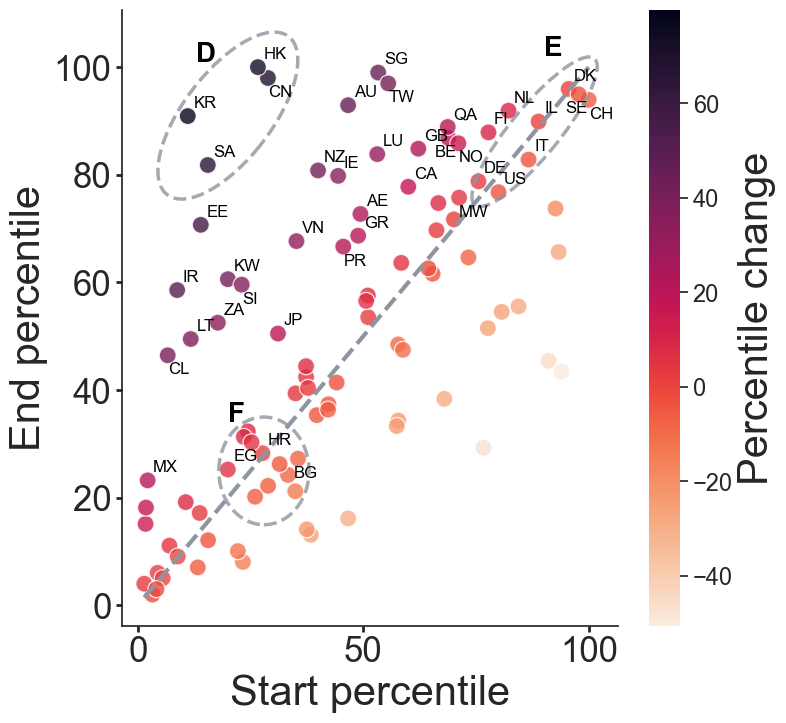

In [18]:
transition_selected=transition_summary[transition_summary['Count']>=1]

fig, ax=plt.subplots(1,1, figsize=(8,8))
performance_plot(ax, result)


# Figure 5

In [ ]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False,"axes.spines.left": True,"ytick.left":True,
                "axes.spines.bottom": True,"xtick.bottom":True,}
sns.set_theme(style='ticks', rc=custom_params)
   

layout = [
    ["A", "B","C"],             
    ["D","E", "F"],             
    ["G", "H", "I"]   
]

fig, axes = plt.subplot_mosaic(layout, figsize=(26,22), 
                                  gridspec_kw={'height_ratios': [1.2,1,1],'width_ratios': [1]*3, "hspace": 0.1, "wspace": 0.1},
                                 constrained_layout=True, )


for label, ax in axes.items():
    ax.set_title(label, loc='left', fontweight='bold', fontsize=30, )  # Title at the upper left corner
    ax.title.set_x(-10)


quadrant_probability(axes['A'])

transition_selected=transition_summary[transition_summary['Count']>=1]
plot_chord_diagram(transition_selected, ax=axes['B'])

performance_plot(axes['C'],result)



group1=['BR','CN','TR','IN',]
#group2=['CA','AU','DE','GB','US']
group3=['RU','ZA','IT','NZ','IL']
group4=['NL','SE','GB','CH','CA','AU','DE','FR','US']



plot_collab_vs_self_sequence(axes['D'],dfself,['KR','SA','HK','CN'],False)
axes["D"].set_xlabel('', fontsize=30)
axes["D"].set_ylabel('Fraction with international authors', fontsize=30)


plot_collab_vs_self_sequence(axes['E'],dfself,['SE','CH','DE','US'],False)
axes["E"].set_xlabel('Citation self-preference', fontsize=30)
axes["E"].set_ylabel('', fontsize=30)

plot_collab_vs_self_sequence(axes['F'],dfself,['HR','EG','BG'],False)
axes["F"].set_xlabel('', fontsize=30)
axes["F"].set_ylabel('', fontsize=30)


plot_collab_vs_self_sequence(axes['G'],dfself,['TW','CN',],True)
axes["G"].set_xlabel('', fontsize=30)
axes["G"].set_ylabel('', fontsize=30)
axes["G"].set_ylabel('Fraction with international authors', fontsize=30)


plot_collab_vs_self_sequence(axes['H'],dfself,['KR','IL',],True)
axes["H"].set_xlabel('', fontsize=30)
axes["H"].set_ylabel('', fontsize=30)
axes["H"].set_xlabel('Citation self-preference', fontsize=30)



plot_collab_vs_self_sequence(axes['I'],dfself,['SA','AR',],True)
axes["I"].set_xlabel('', fontsize=30)
axes["I"].set_ylabel('', fontsize=30)


plt.savefig(f"../output/figures/country_trajectories_bootstrap.pdf", bbox_inches='tight')

# Figure 5 Panels D-I

In [24]:
def plot_collab_vs_self_sequence(ax,data,countries_of_interest, comparison=True):
    
    import copy

    data=copy.deepcopy(data)
    
    
    data['Year']=data['Year'].astype(int)

    data['Decade'] = (data['Year'] // 10) * 10
    
    unique_decades = sorted(data['Decade'].unique())
   
    decade_colors=['#F6C3A3','#DA6437', '#931B5B']
    
    decade_colors =decade_colors[0: len(unique_decades)]  # or use 'Set1', 'tab10', etc.

    decade_color_dict = dict(zip(unique_decades, decade_colors))

    num_quantiles = 4
    quantile_labels = [1,2,3,4]
        
    filtered_df = data[data['Country'].isin(countries_of_interest)]
    filtered_df.sort_values(by=['Country','Year'], inplace=True)

    marker_styles = ['o', 's', 'X', 'P', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', '8']
    style_dict = dict(zip(countries_of_interest, marker_styles[:len(countries_of_interest)]))


    measure='logzscore'

    filtered_df['YearNorm'] = (filtered_df['Year'] - filtered_df['Year'].min()) / (filtered_df['Year'].max() - filtered_df['Year'].min())

    for country in countries_of_interest:
        country_data = filtered_df[filtered_df['Country'] == country]
        if not country_data.empty:
            for decade in country_data['Decade'].unique():
                decade_data = country_data[country_data['Decade'] == decade]
                
                axx=sns.scatterplot(ax=ax, data=decade_data, 
                               x=measure, y='FracInternationalAuthors',
                               color=decade_color_dict[decade],  # Color by decade
                               s=80,  
                               legend=False, marker=style_dict[country]
                            )

    for spine in axx.spines.values():
        spine.set_linewidth(1.5) 

    
    size=17
    
    for country in countries_of_interest:
        country_data = filtered_df[filtered_df['Country'] == country]
        first_year = country_data.loc[country_data['Year'].idxmin()]
        last_year = country_data.loc[country_data['Year'].idxmax()]
        
        first_decade = (first_year['Year'] // 10) * 10
        last_decade = (last_year['Year'] // 10) * 10
        first_color = decade_color_dict[first_decade]
        last_color = decade_color_dict[last_decade]

        if comparison==True:
            if countries_of_interest.index(country)==0:
                axx.annotate(f"{first_year['Year']}", 
                         (first_year[measure], first_year['FracInternationalAuthors']-0.067),
                         textcoords="offset points", xytext=(0, 0), ha='center',
                             color='black', fontsize=size)
        else:
            if country in ['KR']:
                 axx.annotate(f"{first_year['Year']}", 
                 (first_year[measure]+0.15, first_year['FracInternationalAuthors']+0.02),
                 textcoords="offset points", xytext=(0, 0), ha='center',
                     color='black', fontsize=size)   
            elif country in ['CH','HR']:
                 axx.annotate(f"{first_year['Year']}", 
                 (first_year[measure]-0.15, first_year['FracInternationalAuthors']-0.03),
                 textcoords="offset points", xytext=(0, 0), ha='center',
                     color='black', fontsize=size)   
            
            else:
                axx.annotate(f"{first_year['Year']}", 
                 (first_year[measure], first_year['FracInternationalAuthors']-0.06),
                 textcoords="offset points", xytext=(0, 0), ha='center',
                     color='black', fontsize=size)
    
            
        if country in ['SE','BG']:
            
            axx.annotate(f"{country}\n{last_year['Year']}", 
                     (last_year[measure]+0.1, last_year['FracInternationalAuthors']),
                     textcoords="offset points", xytext=(0, 5), ha='center', color='black',fontsize=size)

        
        elif country in ['HR']:
            
            axx.annotate(f"{country}\n{last_year['Year']}", 
                     (last_year[measure]-0.1, last_year['FracInternationalAuthors']),
                     textcoords="offset points", xytext=(0, 5), ha='center', color='black', fontsize=size)
        
        else:
            axx.annotate(f"{country}\n{last_year['Year']}", 
                     (last_year[measure], last_year['FracInternationalAuthors']),
                     textcoords="offset points", xytext=(0, 5), ha='center', color='black', fontsize=size)
   
    axx.set_xlim([0.3,2.8])
    axx.set_ylim([0,0.8])
    
    axx.tick_params(labelsize=25) 

# Table S13: Countries maintaining stable quadrant positions from 1990 to 2019 (𝑁=28 countries).

In [28]:
stable_countries.sort_values(by='Stable_Quadrant')

def create_quadrant_summary_table(stable_countries_df):
    """
    Create a summary table with each quadrant and its list of countries
    
    Parameters:
    stable_countries_df: DataFrame from the analyze_quadrant_transitions function
    
    Returns:
    DataFrame with quadrants and their countries
    """
    
    quadrant_groups = stable_countries_df.groupby('Stable_Quadrant')['Country'].apply(list).reset_index()
    
    quadrant_groups['Countries'] = quadrant_groups['Country'].apply(lambda x: ', '.join(sorted(x)))
    
    quadrant_groups['Country_Count'] = quadrant_groups['Country'].apply(len)
    
    result = quadrant_groups[['Stable_Quadrant', 'Country_Count', 'Countries']].copy()
    result = result.sort_values('Country_Count', ascending=False).reset_index(drop=True)
    
    return result

stable_countries = create_quadrant_summary_table(stable_countries)

In [29]:
latex=stable_countries.to_latex(index=False, position='H', label='tab:SI_stable', 
                                caption='Countries maintaining stable quadrant positions from 1990 to 2019 ($N$=28 countries).')
print(latex)

\begin{table}[H]
\caption{stable countries}
\label{tab:stable}
\begin{tabular}{lrl}
\toprule
Stable_Quadrant & Country_Count & Countries \\
\midrule
Dependent collaborators & 15 & AE, AM, BF, BJ, CM, CY, EE, IS, MW, PA, PR, QA, SD, UY, ZM \\
Independent nations & 4 & ES, IN, JP, US \\
Self-sufficient collaborators & 3 & CH, NL, SE \\
Peripheral nations & 2 & CR, CU \\
\bottomrule
\end{tabular}
\end{table}



In [845]:
stable_countries

,Stable_Quadrant,Country_Count,Countries
0,Dependent collaborators,16,"AE, AM, BF, BJ, CM, CY, EE, IS, LB, MW, PA, PR..."
1,Independent nations,6,"BR, ES, IN, JP, US, ZA"
2,Peripheral nations,3,"CR, CU, PE"
3,Self-sufficient collaborators,3,"CH, NL, SE"


# Figure S13: Country positioning in collaboration-self-relianc space, 1990 versus 2019. 

In [30]:
    
def space_scatter(df_start, legend, title, ax):
    
    sns_deep = sns.color_palette("deep", 10)
    colours=['#8D95A0','#2171b5','#DA6437',]
        
    custom_palette = {
        'Self-sufficient collaborators': colours[1],   
        'Independent nations': colours[2],  # Blue
        'Dependent collaborators': sns_deep[4],   # Green
        'Peripheral nations': colours[0]                  # Gray
    }
        
    sns.scatterplot(data=df_start, x='logzscore', y='FracInternationalAuthors', 
                    hue='quadrant', s=100, palette=custom_palette, ax=ax)
    
    legend_order = ['Self-sufficient collaborators','Independent nations',  'Dependent collaborators', 'Peripheral nations']
    handles, labels = ax.get_legend_handles_labels()
    
    ordered_handles = []
    ordered_labels = []
    for quadrant in legend_order:
        if quadrant in labels:
            idx = labels.index(quadrant)
            ordered_handles.append(handles[idx])
            ordered_labels.append(labels[idx])
    
    # Create ordered legend
    if legend==True:
        legend = ax.legend(handles=ordered_handles, labels=ordered_labels, frameon=False, fontsize=20)
    else:
        ax.legend().remove()  
        
    
    # Color legend text to match points
    
    ax.tick_params(labelsize=23) 
    ax.set_xlabel('Citation self-preference', fontsize=25)
    ax.set_ylabel('International collaboration', fontsize=25)

    # Add text at relative coordinates
    ax.text(0.1, 1.07, title, 
            transform=ax.transAxes,  # Use relative coordinates
            fontsize=23, 
            ha='left', va='top')

    ax.set_xlim([0.4,2.5])
    ax.set_ylim([0,0.9])

In [ ]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False,"axes.spines.left": True,"ytick.left":True,
                "axes.spines.bottom": True,"xtick.bottom":True,}
sns.set_theme(style='ticks', rc=custom_params)
   

layout = [
    ["A", 'B',]
]

fig, axes = plt.subplot_mosaic(layout, figsize=(16,6), 
                                  gridspec_kw={'height_ratios': [1], 'width_ratios': [1,1], "hspace": 0.1, "wspace": 0.1},
                                 constrained_layout=True, )
for label, ax in axes.items():
    ax.set_title(label, loc='left', fontweight='bold', fontsize=25, )  # Title at the upper left corner
    ax.title.set_x(-10)


#df_start=df_with_quadrants.sort_values(by=['Country','Year']).drop_duplicates(subset=['Country'])
df_start=df_with_quadrants[df_with_quadrants['Year']==1990]
space_scatter(df_start,True,1990, axes['A'])

for index, row in df_start.iterrows():

    if row['Country'] in ['CN','AR']:
       
        axes['A'].annotate(row['Country'], (row['logzscore'], row['FracInternationalAuthors']),
                xytext=(1, -5), textcoords='offset points', 
                fontsize=12, ha='left', va='bottom')
    
    elif row['Country'] in ['TW','IL','SA']:
       
        axes['A'].annotate(row['Country'], (row['logzscore'], row['FracInternationalAuthors']),
                xytext=(0, 0), textcoords='offset points', 
                fontsize=12, ha='left', va='bottom')

    elif row['Country'] in ['KR']:
       
         axes['A'].annotate(row['Country'], (row['logzscore'], row['FracInternationalAuthors']),
                 xytext=(-12,-13), textcoords='offset points', 
                 fontsize=12, ha='left', va='bottom')
    else:
        continue



countries=df_start['Country'].unique()

df_end=df_with_quadrants[df_with_quadrants['Year']==2019]
#df_end=df_end[df_end['Country'].isin(countries)]
space_scatter(df_end,False,2019, axes['B'])

for index, row in df_end.iterrows():

    if row['Country'] in ['TW','CN','IL','KR','SA']:
       
        axes['B'].annotate(row['Country'], (row['logzscore'], row['FracInternationalAuthors']),
                xytext=(0, 0), textcoords='offset points', 
                fontsize=12, ha='left', va='bottom')

    elif row['Country'] in ['AR']:
       
        axes['B'].annotate(row['Country'], (row['logzscore'], row['FracInternationalAuthors']),
                xytext=(-8, -15), textcoords='offset points', 
                fontsize=12, ha='left', va='bottom')

        
# Add lines between country pairs
country_pairs = [('TW', 'CN'), ('IL', 'KR'), ('SA', 'AR')]

for pair in country_pairs:
    country1, country2 = pair
    
    # Get coordinates for both countries
    country1_data = df_end[df_end['Country'] == country1]
    country2_data = df_end[df_end['Country'] == country2]
    
    if not country1_data.empty and not country2_data.empty:
        x1, y1 = country1_data['logzscore'].iloc[0], country1_data['FracInternationalAuthors'].iloc[0]
        x2, y2 = country2_data['logzscore'].iloc[0], country2_data['FracInternationalAuthors'].iloc[0]
        
        axes['B'].annotate('', xy=(x2, y2), xytext=(x1, y1),
                          arrowprops=dict(arrowstyle='<->', 
                                        color='black', 
                                        linewidth=2.5,
                                        alpha=0.55), zorder=0)



plt.savefig(f"../output/figures/SI_1990vs2019_bootstrap.pdf", bbox_inches='tight')